In [68]:
from dotenv import load_dotenv
load_dotenv()

True

In [69]:
from langgraph.graph import START,END, StateGraph
from langchain_groq import ChatGroq
from pydantic import BaseModel,Field
from typing import Literal

In [70]:
llm = ChatGroq(
    model="openai/gpt-oss-20b"
)

In [71]:
class llm_schema(BaseModel):
    category: Literal['insta', 'twitter', 'linkedin'] = Field(..., description="Category of the post to generate")
    topic: str = Field(..., description="Topic of the post to generate")

In [72]:
llm_with_schema = llm.with_structured_output(llm_schema)

In [73]:
class graph_schema(BaseModel):
    inp: str
    topic: str
    post: str
    category: str

In [74]:
def decider(state: graph_schema) -> graph_schema:

    user_inp = state.inp

    res = llm_with_schema.invoke(user_inp)

    state.category = res.category
    state.topic = res.topic

    return state

In [75]:
def instaPost(state: graph_schema):
    topic = state.topic

    prompt = f"Write an Instagram post about {topic}. Keep the tone casual and engaging."

    res = llm.invoke(prompt).content

    return {"insta": res}


def twitterPost(state: graph_schema):
    topic = state.topic

    prompt = f"Write a Twitter post about {topic}. Keep the tone quick."

    res = llm.invoke(prompt).content

    return {"post": res}


def linkedinPost(state: graph_schema):
    topic = state.topic

    prompt = f"Write a LinkedIn post about {topic}. Keep the tone professional and informative."

    res = llm.invoke(prompt).content

    return {"linkedin": res}

In [76]:
def condition(state: graph_schema) -> str:

    category = state.category

    if category == 'insta':
        return 'instaPost'
    elif category == 'twitter':
        return 'twitterPost'
    elif category == 'linkedin':
        return 'linkedinPost'
    else:
        raise ValueError("Invalid category")

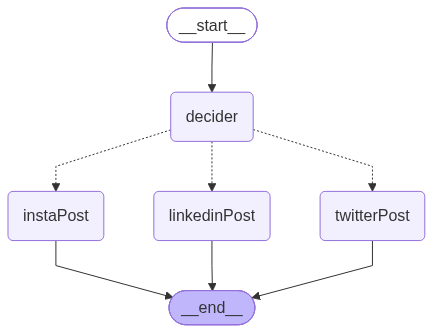

In [77]:
graph = StateGraph(graph_schema)

graph.add_node("decider", decider)
graph.add_node("instaPost", instaPost)
graph.add_node("twitterPost", twitterPost)
graph.add_node("linkedinPost", linkedinPost)


graph.add_edge(START, "decider")
graph.add_conditional_edges("decider",condition,{
    'instaPost': "instaPost",
    'twitterPost': "twitterPost",
    'linkedinPost': "linkedinPost"
})

graph.add_edge("instaPost", END)
graph.add_edge("twitterPost", END)
graph.add_edge("linkedinPost", END) 

graph = graph.compile()
graph

In [78]:
graph.invoke({
    "inp": "I want to generate a post for twitter about AI",
    "topic":"",
    "category":"",
    "post":""
})

{'inp': 'I want to generate a post for twitter about AI',
 'topic': 'AI',
 'post': 'AI is rewriting the rulebook—art, code, decisions, all with a new co‑pilot. 🚀 Embrace the power, but keep ethics in the loop. The future is here, and it’s written in code. #AI #FutureTech #EthicalAI',
 'category': 'twitter'}